# Speech Emotion Recognition - Enhanced Classical Classifier

This notebook builds a speech emotion recognition (SER) classifier using the TESS dataset.
It mirrors the feature set of the reference notebook (MFCC, Chroma, Mel Spectrogram)
but adds a robust audio pre-processing pipeline that includes:
- Noise estimation and spectral subtraction via noisereduce
- Silence/leading-trailing trimming
- Pre-emphasis filtering to boost high-frequency energy
- Normalization to a consistent RMS level

Dataset: Toronto Emotional Speech Set (TESS)
https://www.kaggle.com/datasets/ejlok1/toronto-emotional-speech-set-tess

Emotions covered: angry, disgust, fear, happy, neutral, ps (pleasant surprise), sad

#0. load Kaggle dataset


In [1]:
# # from google.colab import files
# # files.upload()

In [2]:
# load the dataset from kaggle website
# !kaggle datasets download -d ejlok1/toronto-emotional-speech-set-tess

'kaggle' n'est pas reconnu en tant que commande interne
ou externe, un programme ex�cutable ou un fichier de commandes.


In [3]:
# unzip the dataset
# !unzip /content/toronto-emotional-speech-set-tess.zip -d /content/dataset

'unzip' n'est pas reconnu en tant que commande interne
ou externe, un programme ex�cutable ou un fichier de commandes.


## 1. Install Dependencies

In [4]:
# noisereduce provides spectral-gating based noise reduction
# soundfile is the recommended backend for librosa file I/O
# !pip install noisereduce soundfile librosa scikit-learn matplotlib seaborn tqdm --quiet


[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: C:\Users\LENOVO\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


## 2. Imports

In [5]:
import os
import glob
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import librosa
import soundfile as sf
import noisereduce as nr

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

ModuleNotFoundError: No module named 'librosa'

## 3. Configuration

In [ ]:
# Path to the TESS dataset root directory.
DATASET_PATH = r'd:/DL/TESS Toronto emotional speech set data'

# Target sample rate - all files are resampled to this value for consistency
TARGET_SR = 22050

# Number of MFCC coefficients to extract
N_MFCC = 40

# Number of Mel filterbank channels
N_MELS = 128

# Pre-emphasis coefficient - lifts high-frequency components
PRE_EMPHASIS = 0.97

# Top-dB threshold for silence trimming (frames below this are cut)
TRIM_TOP_DB = 30

# Random seed for reproducibility
SEED = 42

# Emotions present in TESS
EMOTIONS = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'ps', 'sad']

## 4. Audio Pre-Processing Pipeline

Each audio file passes through four sequential cleaning stages before feature extraction.

In [ ]:
def load_and_clean_audio(file_path, target_sr=TARGET_SR):
    """
    Load a WAV file and apply a multi-stage cleaning pipeline.

    Stages:
        1. Load & resample  - librosa.load resamples to target_sr using a
           high-quality sinc filter, and converts stereo to mono via averaging.
        2. Noise reduction  - noisereduce.reduce_noise estimates the noise
           profile from the first 0.5 s of the signal (which is typically
           silence) and applies spectral subtraction / gating to suppress
           stationary background noise.
        3. Silence trimming - librosa.effects.trim removes leading and trailing
           frames whose energy is more than TRIM_TOP_DB dB below the peak,
           eliminating dead air at the recording boundaries.
        4. Pre-emphasis      - applies a first-order high-pass FIR filter
           y[t] = x[t] - coef * x[t-1] to compensate for the natural roll-off
           of the vocal tract and improve MFCC quality at higher frequencies.
        5. RMS normalisation - scales the signal so that its RMS equals 0.1,
           making all utterances comparable in loudness.

    Parameters
    ----------
    file_path : str
        Path to the audio file.
    target_sr : int
        Desired sample rate after loading.

    Returns
    -------
    y  : np.ndarray  Cleaned mono audio signal (float32)
    sr : int         Sample rate
    """
    # Stage 1: load and resample
    y, sr = librosa.load(file_path, sr=target_sr, mono=True)

    # Stage 2: spectral noise reduction
    # We use the first 0.5 s as a noise reference (quiet segment).
    # prop_decrease controls how aggressively noise is reduced (0-1).
    noise_clip = y[:int(0.5 * sr)] if len(y) > int(0.5 * sr) else y
    y = nr.reduce_noise(
        y=y,
        sr=sr,
        y_noise=noise_clip,
        prop_decrease=0.75,
        stationary=False  # non-stationary mode adapts to changing noise
    )

    # Stage 3: trim silence from boundaries
    y, _ = librosa.effects.trim(y, top_db=TRIM_TOP_DB)

    # Guard: if trimming removes everything, restore the original load
    if len(y) == 0:
        y, sr = librosa.load(file_path, sr=target_sr, mono=True)

    # Stage 4: pre-emphasis filter
    y = np.append(y[0], y[1:] - PRE_EMPHASIS * y[:-1])

    # Stage 5: RMS normalisation
    rms = np.sqrt(np.mean(y ** 2))
    if rms > 0:
        y = y * (0.1 / rms)

    return y.astype(np.float32), sr

## 5. Feature Extraction

We replicate the three feature groups used in the reference notebook, applied to the cleaned signal.

In [ ]:
def extract_features(y, sr, n_mfcc=N_MFCC, n_mels=N_MELS):
    """
    Extract a fixed-length feature vector from a cleaned audio signal.

    Features
    --------
    MFCC (40 dims)
        Mel-Frequency Cepstral Coefficients encode the spectral envelope
        of the signal on a perceptual Mel scale. We take the mean across
        time frames to obtain a single scalar per coefficient.
    MFCC Delta (40 dims)
        First-order temporal derivatives of MFCC capture the rate of
        spectral change - important for distinguishing emotions.
    Chroma STFT (12 dims)
        Projects the spectrum onto the 12 semitone pitch classes. Useful
        for capturing tonal information in emotional speech.
    Mel Spectrogram (128 dims)
        Mean energy in each Mel filterbank channel over time. Provides
        a compact but rich spectro-temporal summary.
    ZCR (1 dim)
        Zero-Crossing Rate reflects the noisiness / voicing of the signal.
    RMS (1 dim)
        Root-Mean-Square energy captures loudness/intensity.

    Total: 222-dimensional vector.

    Parameters
    ----------
    y  : np.ndarray  Audio signal
    sr : int         Sample rate

    Returns
    -------
    np.ndarray  Feature vector of shape (222,)
    """
    features = []

    # MFCC - shape (n_mfcc, T) -> mean over T
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    features.append(np.mean(mfccs, axis=1))

    # MFCC Delta - first-order difference along time axis
    mfcc_delta = librosa.feature.delta(mfccs)
    features.append(np.mean(mfcc_delta, axis=1))

    # Chroma STFT - uses the magnitude spectrogram computed from STFT
    stft_mag = np.abs(librosa.stft(y))
    chroma = librosa.feature.chroma_stft(S=stft_mag, sr=sr)
    features.append(np.mean(chroma, axis=1))

    # Mel Spectrogram
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
    features.append(np.mean(mel, axis=1))

    # Zero-Crossing Rate
    zcr = librosa.feature.zero_crossing_rate(y)
    features.append([np.mean(zcr)])

    # RMS Energy
    rms = librosa.feature.rms(y=y)
    features.append([np.mean(rms)])

    return np.hstack(features)

## 6. Build Dataset

In [ ]:
def discover_files(dataset_path):
    """
    Walk the TESS directory tree and collect (file_path, emotion) pairs.

    TESS directory structure:
        <root>/YAF_<word>_<emotion>.wav   (young adult female)
        <root>/OAF_<word>_<emotion>.wav   (older adult female)

    The emotion label is embedded in the filename as the last underscore-
    separated token before the extension.
    """
    records = []
    for path in glob.glob(os.path.join(dataset_path, '**', '*.wav'), recursive=True):
        basename = os.path.splitext(os.path.basename(path))[0]
        emotion = basename.split('_')[-1].lower()
        if emotion in EMOTIONS:
            records.append({'path': path, 'emotion': emotion})
    return pd.DataFrame(records)


df = discover_files(DATASET_PATH)
print(f'Total audio files found: {len(df)}')
print(df['emotion'].value_counts())

Total audio files found: 2800
emotion
angry      400
disgust    400
happy      400
sad        400
neutral    400
ps         400
fear       400
Name: count, dtype: int64


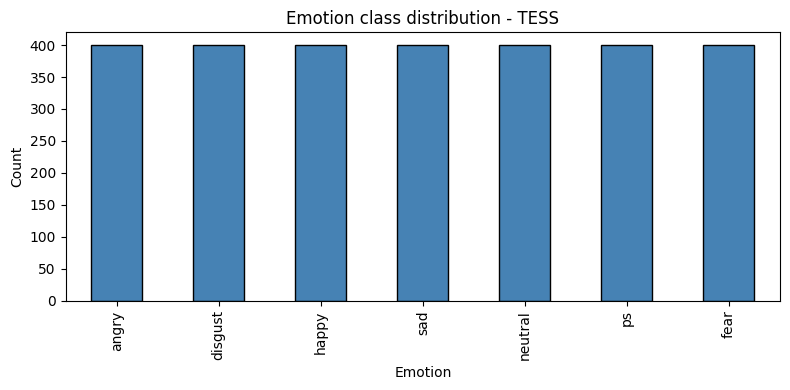

In [ ]:
# Visualise class distribution
fig, ax = plt.subplots(figsize=(8, 4))
df['emotion'].value_counts().plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Emotion class distribution - TESS')
ax.set_xlabel('Emotion')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

In [ ]:
# Extract features for every file.
# tqdm shows a progress bar because this step can take several minutes.
X_list, y_list = [], []

for _, row in tqdm(df.iterrows(), total=len(df), desc='Extracting features'):
    try:
        audio, sr = load_and_clean_audio(row['path'])
        feats = extract_features(audio, sr)
        X_list.append(feats)
        y_list.append(row['emotion'])
    except Exception as e:
        print(f'Skipping {row["path"]} - {e}')

X = np.array(X_list)
y_raw = np.array(y_list)
print(f'Feature matrix shape: {X.shape}')

Extracting features: 100%|██████████| 2800/2800 [06:31<00:00,  7.15it/s]

Feature matrix shape: (2800, 222)


## 7. Encode Labels, Scale Features, Split Data

In [ ]:
# LabelEncoder maps string labels to integers (e.g. 'angry' -> 0)
le = LabelEncoder()
y_enc = le.fit_transform(y_raw)

# Stratified split preserves class proportions in both subsets.
# NOTE: We split FIRST, before applying the scaler to prevent Data Leakage!
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=SEED, stratify=y_enc
)

# StandardScaler z-scores each feature dimension to zero mean / unit variance.
# We fit ONLY on the training data, and then transform the test data.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f'Train set: {X_train.shape}, Test set: {X_test.shape}')

Train set: (2240, 222), Test set: (560, 222)


## 8. Train MLP Classifier

In [ ]:
# Multi-Layer Perceptron with three hidden layers.
# adam optimiser with a decaying learning rate schedule works well for
# high-dimensional feature vectors.
# early_stopping monitors validation loss and halts training when it
# stops improving, reducing the risk of overfitting.
mlp = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64),
    activation='relu',
    solver='adam',
    alpha=0.01,           # L2 regularisation weight
    batch_size=64,
    learning_rate='adaptive',
    max_iter=300,
    random_state=SEED,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    verbose=True
)

mlp.fit(X_train, y_train)

Iteration 1, loss = 0.42232134
Validation score: 0.991071
Iteration 2, loss = 0.01154177
Validation score: 0.982143
Iteration 3, loss = 0.00279794
Validation score: 0.991071
Iteration 4, loss = 0.00146613
Validation score: 1.000000
Iteration 5, loss = 0.00116639
Validation score: 1.000000
Iteration 6, loss = 0.00106984
Validation score: 1.000000
Iteration 7, loss = 0.00099413
Validation score: 1.000000
Iteration 8, loss = 0.00094082
Validation score: 1.000000
Iteration 9, loss = 0.00090208
Validation score: 1.000000
Iteration 10, loss = 0.00087056
Validation score: 1.000000
Iteration 11, loss = 0.00084371
Validation score: 1.000000
Iteration 12, loss = 0.00082175
Validation score: 1.000000
Iteration 13, loss = 0.00080451
Validation score: 1.000000
Iteration 14, loss = 0.00078968
Validation score: 1.000000
Iteration 15, loss = 0.00077879
Validation score: 1.000000
Iteration 16, loss = 0.00076866
Validation score: 1.000000
Iteration 17, loss = 0.00076069
Validation score: 1.000000
Iterat

MLPClassifier(batch_size=64, early_stopping=True,
              hidden_layer_sizes=(512, 256, 128), learning_rate='adaptive',
              max_iter=300, n_iter_no_change=20, random_state=42, verbose=True)

## 9. Evaluate

In [ ]:
y_pred = mlp.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f'Test accuracy: {acc:.4f}\n')
print(classification_report(y_test, y_pred, target_names=le.classes_))

Test accuracy: 0.9964

              precision    recall  f1-score   support

       angry       0.99      1.00      0.99        80
     disgust       0.99      1.00      0.99        80
        fear       1.00      1.00      1.00        80
       happy       1.00      1.00      1.00        80
     neutral       1.00      1.00      1.00        80
          ps       1.00      0.97      0.99        80
         sad       1.00      1.00      1.00        80

    accuracy                           1.00       560
   macro avg       1.00      1.00      1.00       560
weighted avg       1.00      1.00      1.00       560



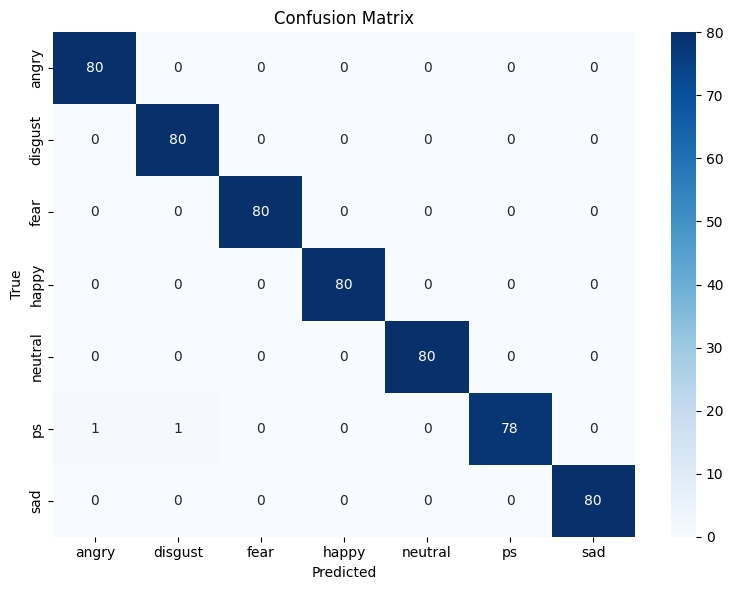

In [ ]:
# Confusion matrix - rows are true labels, columns are predictions.
# A good model shows high values only on the diagonal.
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=le.classes_, yticklabels=le.classes_, ax=ax
)
ax.set_title('Confusion Matrix')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
plt.tight_layout()
plt.show()

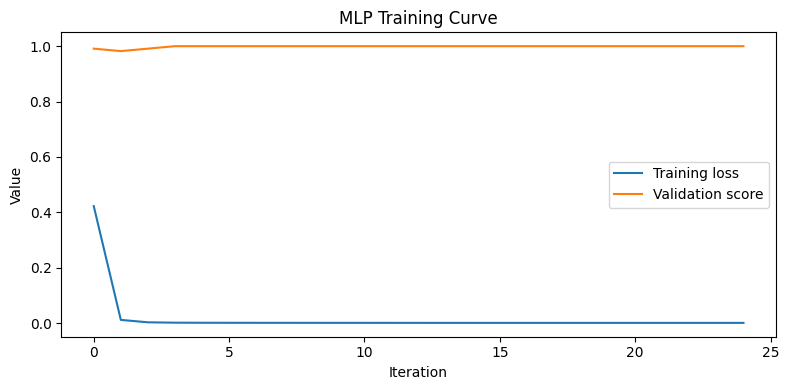

In [ ]:
# Training loss curve - shows how cross-entropy decreased per iteration.
plt.figure(figsize=(8, 4))
plt.plot(mlp.loss_curve_, label='Training loss')
if mlp.best_validation_score_ is not None:
    plt.plot(mlp.validation_scores_, label='Validation score')
plt.xlabel('Iteration')
plt.ylabel('Value')
plt.title('MLP Training Curve')
plt.legend()
plt.tight_layout()
plt.show()

## 10. Save Model Artifacts

In [ ]:
import joblib

# Persist the trained classifier, scaler, and label encoder so that
# Notebook 3 can load them without re-training.
joblib.dump(mlp,    'ser_mlp_model.pkl')
joblib.dump(scaler, 'ser_scaler.pkl')
joblib.dump(le,     'ser_label_encoder.pkl')

print('Saved: ser_mlp_model.pkl, ser_scaler.pkl, ser_label_encoder.pkl')

Saved: ser_mlp_model.pkl, ser_scaler.pkl, ser_label_encoder.pkl
